In [3]:
import pandas as pd

In [8]:
import pandas as pd
df=pd.read_csv("netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In this section, we analyze how Netflix expanded its content catalog overtime, focusing on movies and TV shows 

In [ ]:
df.info()


<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [14]:
df['release_year'].value_counts().head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

In [15]:
df.groupby('type')['release_year'].value_counts()

type     release_year
Movie    2017            767
         2018            767
         2016            658
         2019            633
         2020            517
                        ... 
TV Show  1963              1
         1974              1
         1945              1
         1925              1
         1972              1
Name: count, Length: 119, dtype: int64

In [49]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
df['date_year']=df['date_added'].dt.year
df.groupby('type')['date_year'].value_counts().groupby(level=0).head(10)

type     date_year
Movie    2019.0       1424
         2020.0       1284
         2018.0       1237
         2021.0        993
         2017.0        839
         2016.0        253
         2015.0         56
         2014.0         19
         2011.0         13
         2013.0          6
TV Show  2020.0        594
         2019.0        575
         2021.0        505
         2018.0        388
         2017.0        325
         2016.0        165
         2015.0         17
         2014.0          4
         2013.0          4
         2008.0          1
Name: count, dtype: int64

In [27]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


<function matplotlib.pyplot.show(close=None, block=None)>

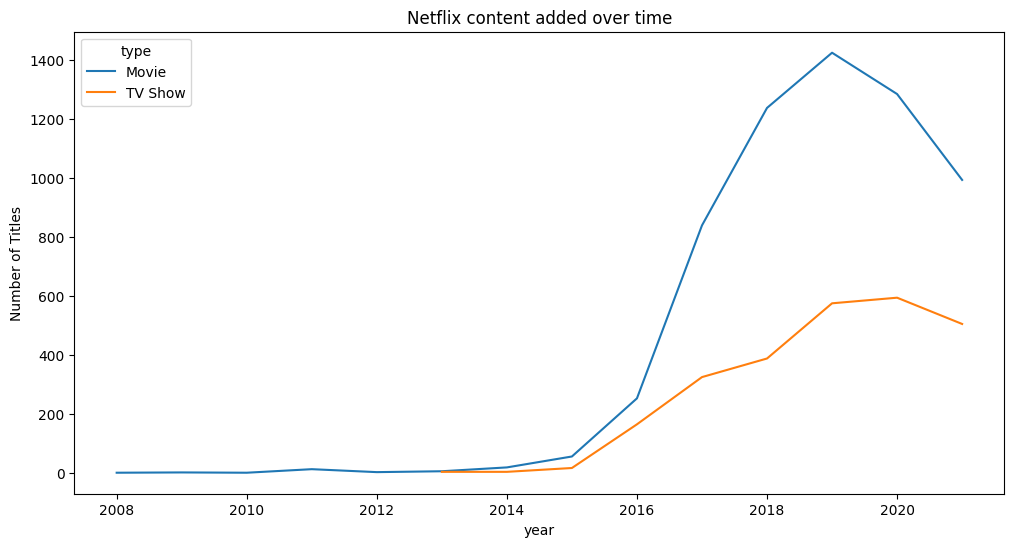

In [30]:
trend=df.groupby(['date_year','type']).size().unstack()
trend.plot(figsize=(12,6))
plt.title('Netflix content added over time')
plt.xlabel('year')
plt.ylabel('Number of Titles')
plt.show

From 2016, movie and tv show experenced rapid expand. Movie still holds the dominate position. TV show starts growing fast after 2016 and reach the peak.
### Key Findings

- Netflix experienced aggressive catalog expansion between 2016 and 2020.
- Movies continue to dominate the platform overall, suggesting that films remain the foundation of Netflix’s content library.
- TV Shows demonstrated particularly strong growth after 2018, potentially reflecting Netflix’s increasing focus on long-term user engagement and binge-watching behavior.

## Business Question 
- How has Netflix evolve into a global platform?

## Methodology

- To investigate Netflix’s global expansion strategy, the analysis focuses on country-level content distribution and temporal growth trends.

Missing values in the `country` column were excluded only for country-specific analyses. Content rankings were first examined to identify the major contributing countries and regions, followed by trend analysis over time for the top-performing countries.

In [50]:
df_country=df.dropna(subset=['country'])
df_country['country'].isnull().sum()
df_country['country'].value_counts().head(20)

country
United States                    2818
India                             972
United Kingdom                    419
Japan                             245
South Korea                       199
Canada                            181
Spain                             145
France                            124
Mexico                            110
Egypt                             106
Turkey                            105
Nigeria                            95
Australia                          87
Taiwan                             81
Indonesia                          79
Brazil                             77
United Kingdom, United States      75
Philippines                        75
United States, Canada              73
Germany                            67
Name: count, dtype: int64

In [38]:
top_countries=df_country['country'].value_counts().head(20)

## Visualization

Text(0, 0.5, 'Country')

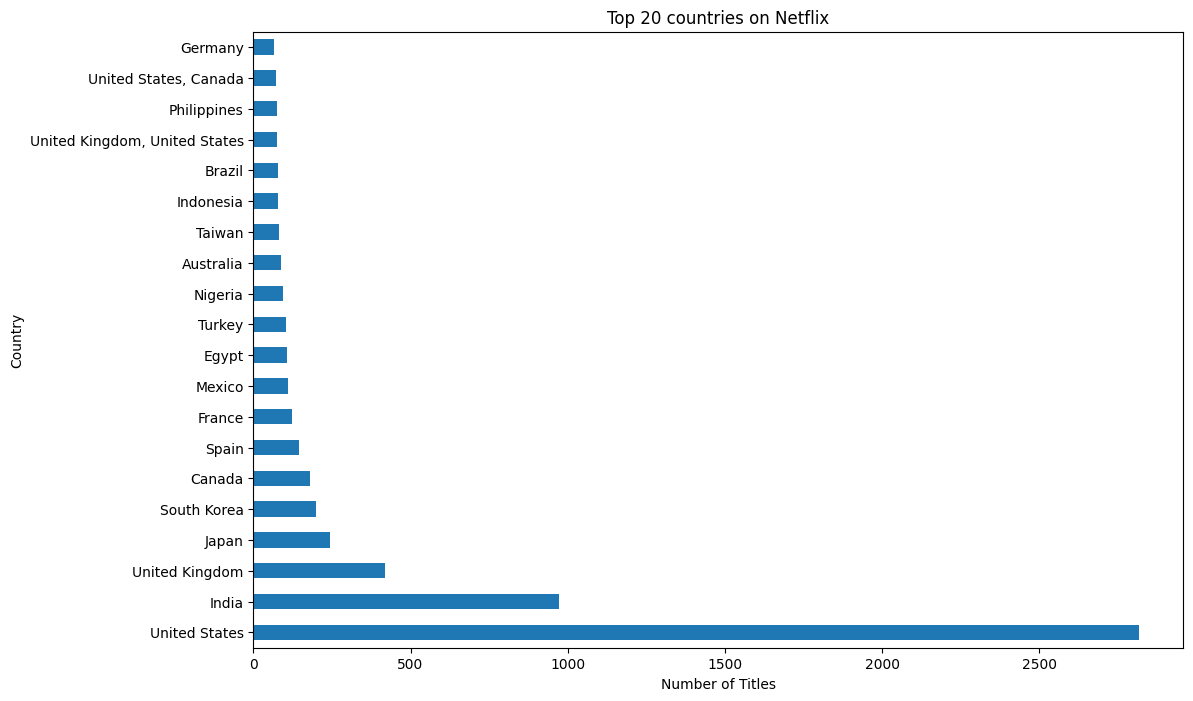

In [39]:
top_countries.plot(kind='barh',figsize=(12,8))
plt.title('Top 20 countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')


- ## Key Findings

- The United States contributes the largest share of Netflix titles by a substantial margin, with the number of U.S. titles exceeding more than twice that of India, the second-largest contributor.
- The United Kingdom ranks third, although its content volume is considerably lower than that of India.
- Countries ranked between 10th and 20th show relatively modest differences in title counts, suggesting a more balanced distribution among emerging international markets.
- Overall, the findings indicate that while Netflix has developed an increasingly international catalog, the platform still remains strongly dominated by U.S. productions.
- The growing presence of countries such as South Korea, Japan, Spain, and Turkey may reflect Netflix’s continued efforts to diversify its global content strategy and expand regional audience engagement.

### Netflix Global Content Strategy Analysis


## Asian Market Expansion Analysis

## Business Question

Has Netflix increasingly expanded its investment in Asian content markets over time?

## Hypothesis

Netflix has significantly increased Asian content offerings, particularly from countries such as South Korea, India, Japan, and Taiwan, as part of its global content diversification strategy.

In [51]:
asian_countries=['India','South Korea','Japan','Taiwan']
df_asia=df_country[df_country['country'].isin(asian_countries)]



In [52]:
df_asia.groupby(['date_year','country']).size().unstack()

country,India,Japan,South Korea,Taiwan
date_year,,,,
2015.0,NaN,1.0,NaN,NaN
2016.0,10.0,16.0,9.0,24.0
2017.0,141.0,27.0,36.0,11.0
2018.0,333.0,35.0,25.0,8.0
2019.0,203.0,57.0,53.0,20.0
2020.0,189.0,61.0,46.0,10.0
2021.0,95.0,44.0,26.0,8.0


In [54]:
asia_trend=df_asia.groupby(['date_year','country']).size().unstack()

## Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

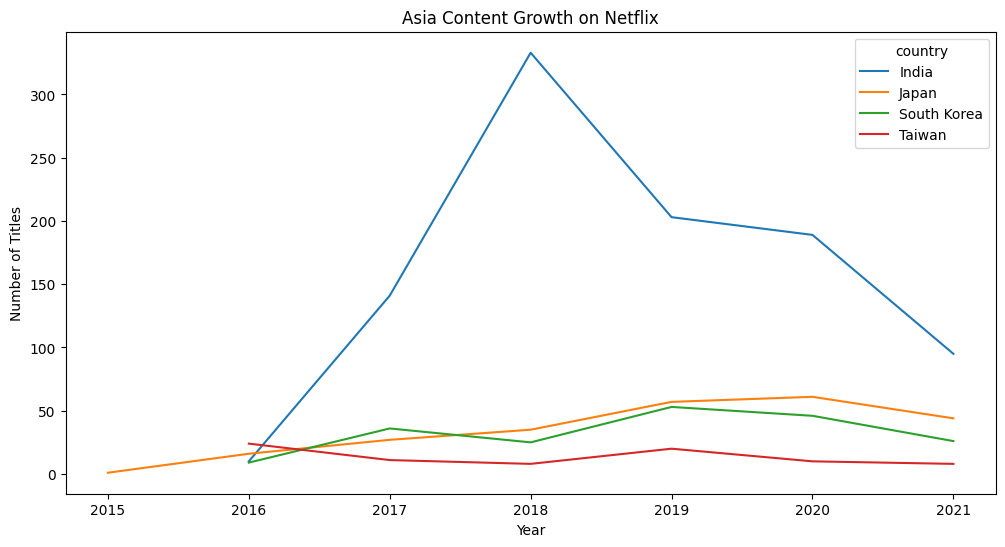

In [55]:
asia_trend.plot(figsize=(12,6))
plt.title('Asia Content Growth on Netflix')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show

### Key Findings

- Indian content experienced substantial growth after 2016 and reached a peak around 2018, suggesting Netflix’s increasing investment in the Indian entertainment market.
- Japanese and South Korean titles demonstrated relatively stable and consistent growth over time. In particular, the continued expansion of Korean content may reflect Netflix’s strategic focus on globally popular K-content and regional audience engagement.
- Taiwanese content remained comparatively limited in scale throughout the observed period, with annual additions remaining relatively stable at lower levels.
- Overall, the findings suggest that Netflix’s Asian content strategy has become increasingly diversified, with India, Japan, and South Korea emerging as key regional contributors to the platform’s international expansion.

## Business Question 
- How has international content collaboration evolved on Netflix over time?
## Hypothesis
- The growth of multinational co-productions may reflect Netflix’s increasing globalization and cross-regional content strategy.

In [62]:
df_country['is_coproduction']=df_country['country'].str.contains(',')
coproduction_trend=df_country.groupby(['date_year','is_coproduction']).size().unstack()
coproduction_trend

is_coproduction,False,True
date_year,,
2008.0,2.0,NaN
2009.0,2.0,NaN
2010.0,1.0,NaN
2011.0,11.0,2.0
2012.0,2.0,1.0
2013.0,8.0,2.0
2014.0,16.0,7.0
2015.0,58.0,12.0
2016.0,329.0,70.0


## Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

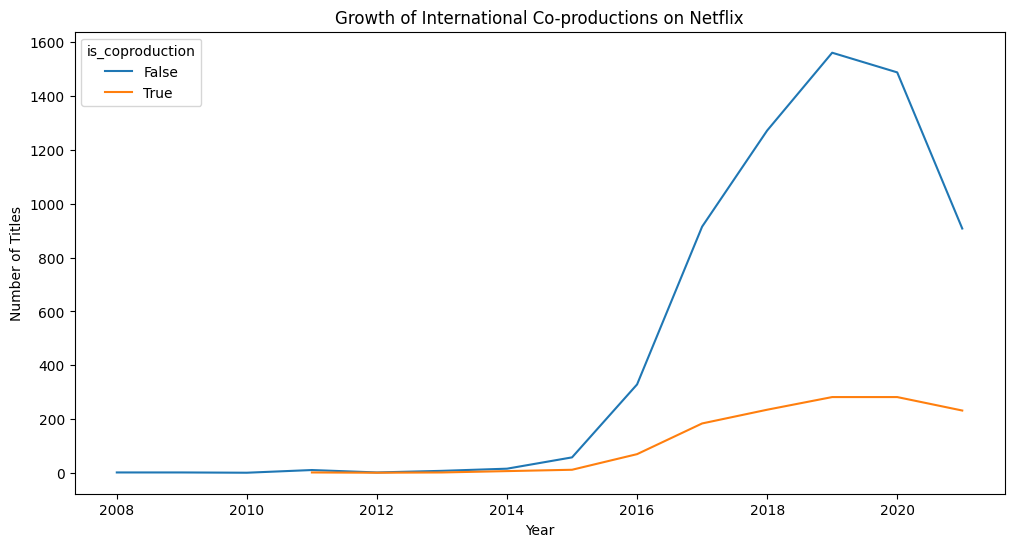

In [63]:
coproduction_trend.plot(figsize=(12,6))
plt.title('Growth of International Co-productions on Netflix')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show

### Visualization Consideration

Although the comparison between co-productions and non-co-productions provides a general overview of Netflix’s catalog composition, this visualization may not effectively capture the globalization trend of co-productions themselves.

Because independently produced titles substantially outnumber multinational co-productions, the scale difference compresses the co-production trend visually and limits interpretability. Therefore, the globalization significance of co-productions should be examined independently rather than primarily through direct comparison with non-co-produced titles.

To better evaluate Netflix’s international collaboration strategy, a separate trend analysis focusing specifically on co-production growth and proportional change over time may provide more meaningful insights.

## proportion trend over time 

# title number each year

In [64]:
total_titles=df_country.groupby('date_year').size()
total_titles

date_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      70
2016.0     399
2017.0    1099
2018.0    1507
2019.0    1843
2020.0    1770
2021.0    1140
dtype: int64

In [65]:
coproduction_titles=df_country[df_country['is_coproduction']].groupby('date_year').size()
coproduction_titles

date_year
2011.0      2
2012.0      1
2013.0      2
2014.0      7
2015.0     12
2016.0     70
2017.0    184
2018.0    235
2019.0    282
2020.0    282
2021.0    232
dtype: int64

In [68]:
coproduction_share=coproduction_titles/total_titles
coproduction_share

date_year
2008.0         NaN
2009.0         NaN
2010.0         NaN
2011.0    0.153846
2012.0    0.333333
2013.0    0.200000
2014.0    0.304348
2015.0    0.171429
2016.0    0.175439
2017.0    0.167425
2018.0    0.155939
2019.0    0.153011
2020.0    0.159322
2021.0    0.203509
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

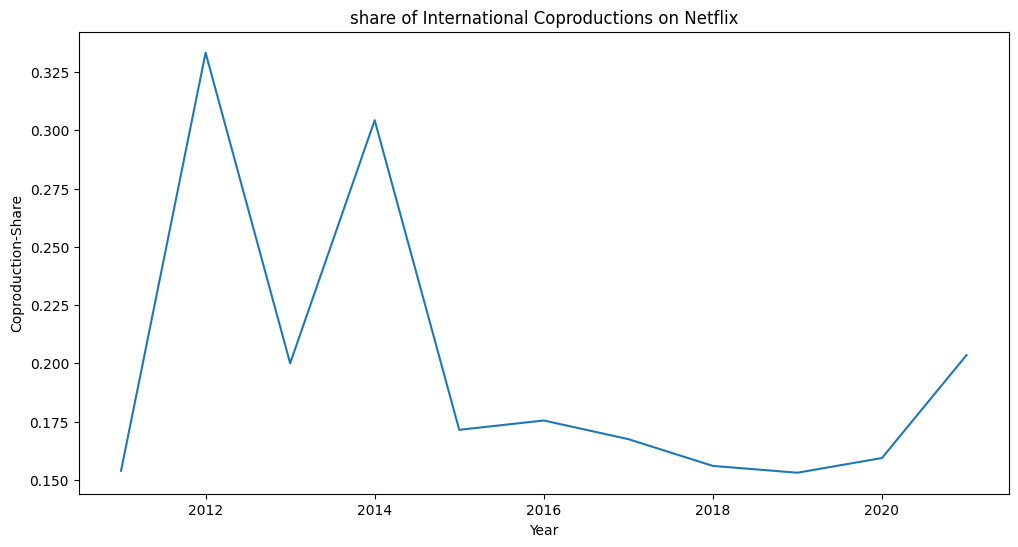

In [70]:
coproduction_share.plot(figsize=(12,6))
plt.title('share of International Coproductions on Netflix')
plt.xlabel('Year')
plt.ylabel('Coproduction-Share')
plt.show

## Key Findings

Although international co-productions increased in absolute numbers after 2015, the proportional share of co-produced titles did not demonstrate a clear and sustained upward trend over time.

The co-production share fluctuated across years, with local peaks observed around 2012 and 2014, followed by a gradual decline after 2016 before recovering slightly in 2021. These results suggest that, within the current dataset, multinational co-productions alone may not provide sufficient evidence to conclusively support a strong globalization trend in Netflix’s content strategy.